# Notebook 03b — NSL calibration diagnostic

**Purpose:** Notebook 03 v2 showed that calibration sometimes makes Brier and ECE *worse* on NSL test set, especially for RF models on the Normal class. This notebook diagnoses why, distinguishing between:

- **Explanation 1 (benign):** NSL test set is distribution-shifted from training (by NSL-KDD's design), so calibrators fit on training-derived data don't transfer perfectly. Honest reportable behaviour.
- **Explanation 2 (concerning):** Per-class one-vs-rest isotonic with renormalisation might be systematically biased when class priors differ between calib and test.

**Strategy:**

1. **Sanity check 1**: Reliability diagrams on the *calibration* set (pre-cal vs post-cal). Post-cal should look near-perfect on calib set. If it doesn't, isotonic isn't fitting properly.
2. **Sanity check 2**: Reliability diagrams on the *test* set (pre-cal vs post-cal). If calib is well-calibrated but test isn't, that's distribution shift, not a bug.
3. **Renormalisation check**: Compare per-class Brier before and after the renormalisation step. If renormalisation makes things worse, that's a design flaw to fix.
4. **Class-prior comparison**: Show calib-vs-test class proportions side by side to make the shift quantitative.

**Scope:** focus on `rf_5class_smote` (worst offender: Normal Brier 0.151→0.192) and `dnn_5class_smote` (intermediate).

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
REPO = '/content/drive/MyDrive/XIDS_Research/xids-research'
os.chdir(REPO)

import numpy as np
import pandas as pd
import json
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss

import warnings
warnings.filterwarnings('ignore')

DATASET = 'nsl_kdd_v2'
PROCESSED = Path(REPO) / 'data' / 'processed' / DATASET
PREDS_DIR = Path(REPO) / 'models' / DATASET / 'predictions'
FIGS_DIR = Path(REPO) / 'results' / 'figures'
FIGS_DIR.mkdir(parents=True, exist_ok=True)

y_calib_5 = np.load(PROCESSED / 'y_calib_5class.npy')
y_test_5 = np.load(PROCESSED / 'y_test_5class.npy')

with open(PROCESSED / 'class_mappings.json') as f:
    class_info = json.load(f)
INT_TO_CATEGORY = {int(k): v for k, v in class_info['multiclass_5'].items()}
CLASS_NAMES_5 = [INT_TO_CATEGORY[i] for i in range(5)]

print(f'Calibration set: {len(y_calib_5):,} samples')
print(f'Test set: {len(y_test_5):,} samples')

Mounted at /content/drive
Calibration set: 25,195 samples
Test set: 22,544 samples


## 2. Quantify the distribution shift

In [2]:
calib_counts = Counter(y_calib_5)
test_counts = Counter(y_test_5)

n_calib = len(y_calib_5)
n_test = len(y_test_5)

rows = []
for c in range(5):
    p_calib = calib_counts[c] / n_calib
    p_test = test_counts[c] / n_test
    rows.append({
        'Class': CLASS_NAMES_5[c],
        'n_calib': calib_counts[c],
        'p_calib (%)': round(100 * p_calib, 2),
        'n_test': test_counts[c],
        'p_test (%)': round(100 * p_test, 2),
        'p_test / p_calib': round(p_test / p_calib, 2) if p_calib > 0 else float('inf'),
    })

df = pd.DataFrame(rows)
print('NSL class-prior comparison: calibration set vs test set')
print('=' * 90)
print(df.to_string(index=False))
print('=' * 90)
print()
print('Interpretation: a ratio far from 1.0 means class priors are shifted between calib and test.')

NSL class-prior comparison: calibration set vs test set
 Class  n_calib  p_calib (%)  n_test  p_test (%)  p_test / p_calib
Normal    13469        53.46    9711       43.08              0.81
   DoS     9186        36.46    7460       33.09              0.91
 Probe     2331         9.25    2421       10.74              1.16
   R2L      199         0.79    2885       12.80             16.20
   U2R       10         0.04      67        0.30              7.49

Interpretation: a ratio far from 1.0 means class priors are shifted between calib and test.


## 3. Reliability diagram helper

In [3]:
def reliability_data(probs, labels, n_bins=10):
    """Compute (mean_confidence, mean_accuracy, weight) per bin for a reliability diagram."""
    bin_edges = np.linspace(0, 1, n_bins + 1)
    data = []
    n = len(probs)
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        if i == n_bins - 1:
            mask = (probs >= lo) & (probs <= hi)
        else:
            mask = (probs >= lo) & (probs < hi)
        if mask.sum() == 0:
            data.append((np.nan, np.nan, 0))
        else:
            data.append((float(probs[mask].mean()), float(labels[mask].mean()), int(mask.sum())))
    return data

def plot_reliability(ax, probs, labels, title, n_bins=10):
    """Plot a reliability diagram on the given axis."""
    data = reliability_data(probs, labels, n_bins)
    confs = [d[0] for d in data]
    accs = [d[1] for d in data]
    weights = [d[2] for d in data]
    total = sum(weights)

    # Perfect calibration line
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Perfect calibration')

    # Scatter sized by bin weight
    sizes = [500 * w / total if total > 0 else 0 for w in weights]
    for conf, acc, sz, w in zip(confs, accs, sizes, weights):
        if not np.isnan(conf):
            ax.scatter(conf, acc, s=max(sz, 20), alpha=0.6, color='steelblue', edgecolor='black')

    # Connect points
    valid_confs = [c for c in confs if not np.isnan(c)]
    valid_accs = [a for a in accs if not np.isnan(a)]
    if len(valid_confs) > 1:
        ax.plot(valid_confs, valid_accs, '-', alpha=0.4, color='steelblue', linewidth=1)

    # Compute ECE for the title
    ece = sum((w/total) * abs(c - a) for c, a, w in zip(confs, accs, weights)
              if not np.isnan(c) and not np.isnan(a) and total > 0)

    brier = float(brier_score_loss(labels, probs))

    ax.set_xlabel('Predicted probability (confidence)')
    ax.set_ylabel('Observed frequency (accuracy)')
    ax.set_title(f'{title}\nBrier={brier:.4f}  ECE={ece:.4f}')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.grid(alpha=0.3)

print('✓ Reliability diagram helper loaded')

✓ Reliability diagram helper loaded


## 4. Diagnostic for rf_5class_smote (worst offender)

Focus: Normal class, where Brier went 0.151 → 0.192. Two key questions: (a) does isotonic fit the calibration set well? (b) does the fit transfer to test set?

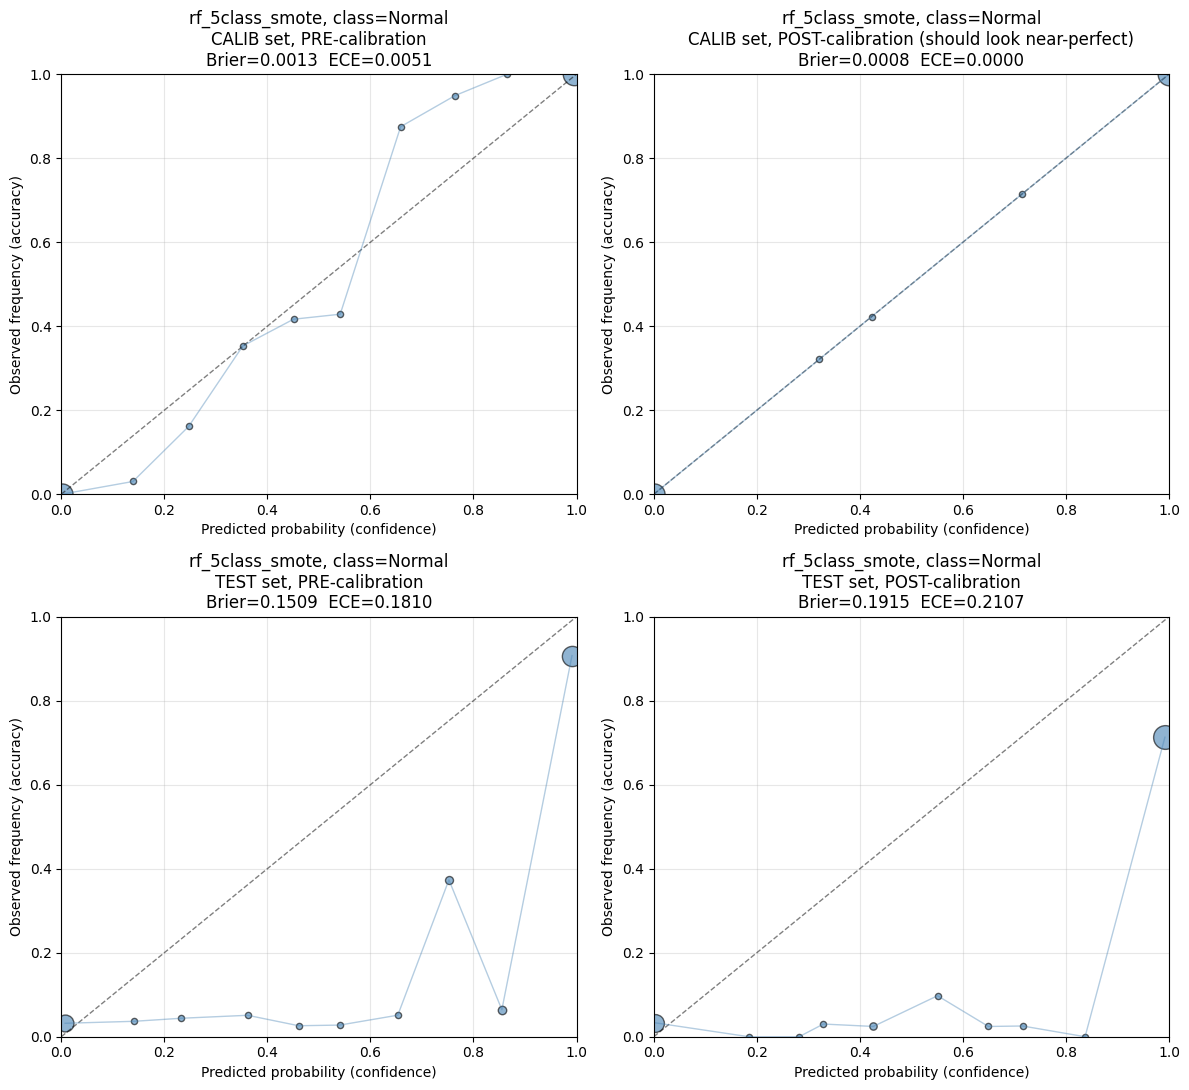


Saved: /content/drive/MyDrive/XIDS_Research/xids-research/results/figures/diag_nsl_rf5smote_normal_reliability.png


In [4]:
name = 'rf_5class_smote'
p_calib = np.load(PREDS_DIR / f'{name}_calib_proba.npy')
p_test = np.load(PREDS_DIR / f'{name}_test_proba.npy')

# Class 0 = Normal
c = 0
y_calib_c = (y_calib_5 == c).astype(int)
y_test_c = (y_test_5 == c).astype(int)
p_calib_c = p_calib[:, c]
p_test_c = p_test[:, c]

# Fit isotonic
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(p_calib_c, y_calib_c)

p_calib_c_cal = iso.predict(p_calib_c)  # post-cal on calibration set
p_test_c_cal = iso.predict(p_test_c)    # post-cal on test set (no renorm)

# Reliability diagrams: 2x2 grid (pre/post x calib/test)
fig, axes = plt.subplots(2, 2, figsize=(12, 11))

plot_reliability(axes[0, 0], p_calib_c,      y_calib_c, f'{name}, class={CLASS_NAMES_5[c]}\nCALIB set, PRE-calibration')
plot_reliability(axes[0, 1], p_calib_c_cal,  y_calib_c, f'{name}, class={CLASS_NAMES_5[c]}\nCALIB set, POST-calibration (should look near-perfect)')
plot_reliability(axes[1, 0], p_test_c,       y_test_c,  f'{name}, class={CLASS_NAMES_5[c]}\nTEST set, PRE-calibration')
plot_reliability(axes[1, 1], p_test_c_cal,   y_test_c,  f'{name}, class={CLASS_NAMES_5[c]}\nTEST set, POST-calibration')

plt.tight_layout()
fig_path = FIGS_DIR / 'diag_nsl_rf5smote_normal_reliability.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'\nSaved: {fig_path}')

## 5. The renormalisation step: does it distort things?

In [5]:
# Reproduce the full per-class isotonic + renorm pipeline for rf_5class_smote
p_test_cal_raw = np.zeros_like(p_test)
for c in range(5):
    y_calib_c = (y_calib_5 == c).astype(int)
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(p_calib[:, c], y_calib_c)
    p_test_cal_raw[:, c] = iso.predict(p_test[:, c])

# Renormalised version
row_sums = p_test_cal_raw.sum(axis=1, keepdims=True)
row_sums = np.where(row_sums == 0, 1, row_sums)
p_test_cal_renorm = p_test_cal_raw / row_sums

# How much does renormalisation change things?
row_sum_stats = p_test_cal_raw.sum(axis=1)
print(f'Row sums BEFORE renorm (these should ideally be ~1):')
print(f'  min={row_sum_stats.min():.4f}  max={row_sum_stats.max():.4f}')
print(f'  mean={row_sum_stats.mean():.4f}  std={row_sum_stats.std():.4f}')
print()

# Per-class Brier: pre-cal, post-cal-raw (no renorm), post-cal-renorm
print(f'Per-class Brier on TEST set: rf_5class_smote')
print(f'{"Class":10s} {"Pre-cal":>10s} {"Post-raw":>10s} {"Post-renorm":>12s} {"Renorm hurt?":>15s}')
print('-' * 70)
for c in range(5):
    y_test_c = (y_test_5 == c).astype(int)
    b_pre = brier_score_loss(y_test_c, p_test[:, c])
    b_raw = brier_score_loss(y_test_c, p_test_cal_raw[:, c])
    b_renorm = brier_score_loss(y_test_c, p_test_cal_renorm[:, c])

    delta_renorm = b_renorm - b_raw
    flag = 'YES (+%.4f)' % delta_renorm if delta_renorm > 0.001 else 'no'

    print(f'{CLASS_NAMES_5[c]:10s} {b_pre:>10.4f} {b_raw:>10.4f} {b_renorm:>12.4f} {flag:>15s}')

Row sums BEFORE renorm (these should ideally be ~1):
  min=0.2487  max=1.7296
  mean=1.0045  std=0.0976

Per-class Brier on TEST set: rf_5class_smote
Class         Pre-cal   Post-raw  Post-renorm    Renorm hurt?
----------------------------------------------------------------------
Normal         0.1509     0.1915       0.1991   YES (+0.0075)
DoS            0.0679     0.0609       0.0646   YES (+0.0037)
Probe          0.0361     0.0415       0.0372              no
R2L            0.1045     0.1193       0.1192              no
U2R            0.0021     0.0028       0.0028              no


## 6. Same diagnostic for dnn_5class_smote (intermediate severity)

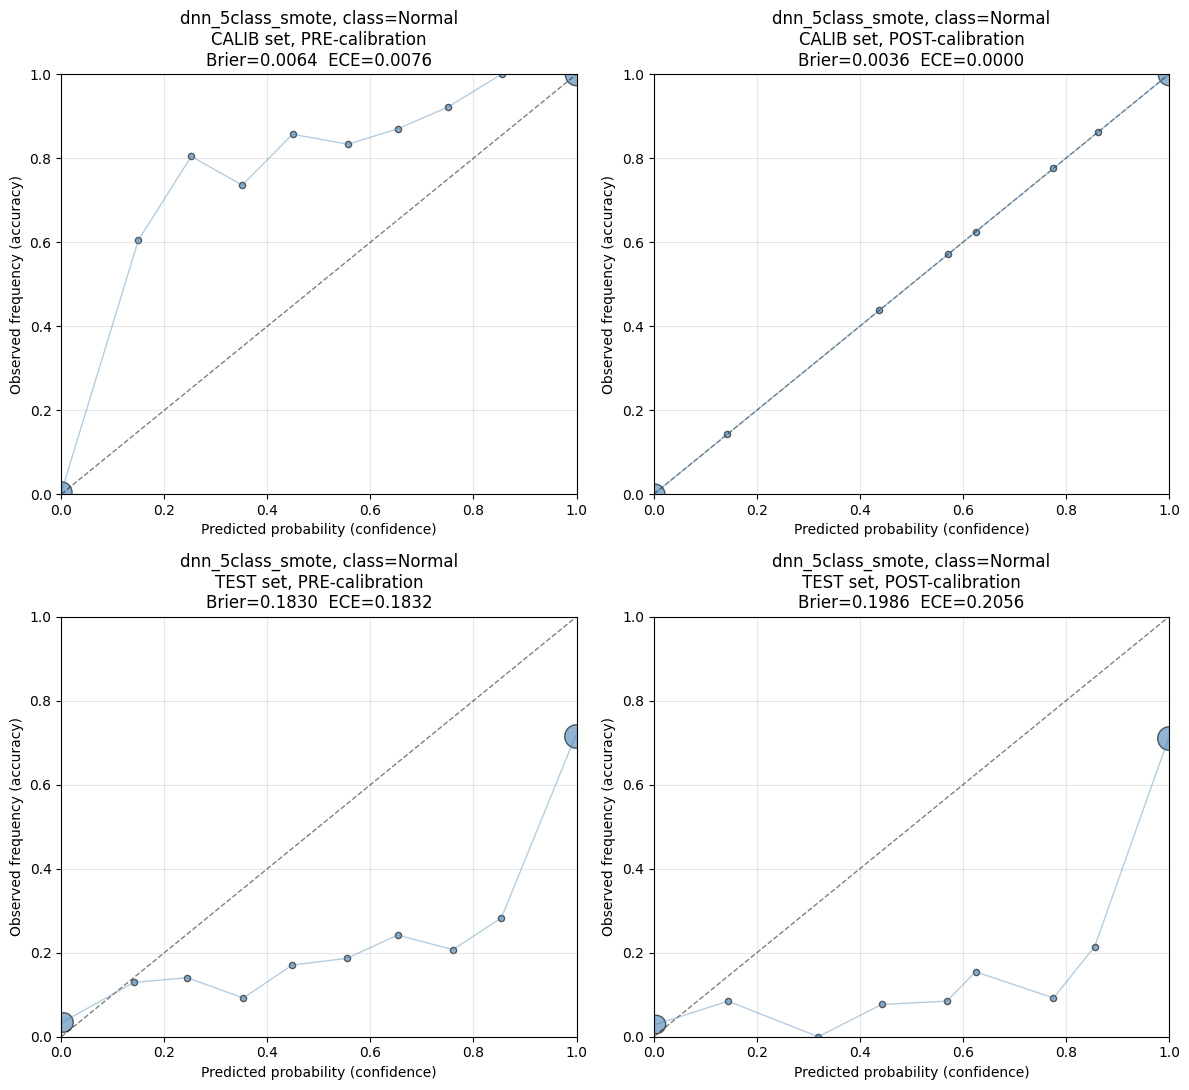


Saved: /content/drive/MyDrive/XIDS_Research/xids-research/results/figures/diag_nsl_dnn5smote_normal_reliability.png


In [6]:
name = 'dnn_5class_smote'
p_calib = np.load(PREDS_DIR / f'{name}_calib_proba.npy')
p_test = np.load(PREDS_DIR / f'{name}_test_proba.npy')

# Class 0 = Normal
c = 0
y_calib_c = (y_calib_5 == c).astype(int)
y_test_c = (y_test_5 == c).astype(int)
p_calib_c = p_calib[:, c]
p_test_c = p_test[:, c]

iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(p_calib_c, y_calib_c)

p_calib_c_cal = iso.predict(p_calib_c)
p_test_c_cal = iso.predict(p_test_c)

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
plot_reliability(axes[0, 0], p_calib_c,      y_calib_c, f'{name}, class={CLASS_NAMES_5[c]}\nCALIB set, PRE-calibration')
plot_reliability(axes[0, 1], p_calib_c_cal,  y_calib_c, f'{name}, class={CLASS_NAMES_5[c]}\nCALIB set, POST-calibration')
plot_reliability(axes[1, 0], p_test_c,       y_test_c,  f'{name}, class={CLASS_NAMES_5[c]}\nTEST set, PRE-calibration')
plot_reliability(axes[1, 1], p_test_c_cal,   y_test_c,  f'{name}, class={CLASS_NAMES_5[c]}\nTEST set, POST-calibration')

plt.tight_layout()
fig_path = FIGS_DIR / 'diag_nsl_dnn5smote_normal_reliability.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'\nSaved: {fig_path}')

## 7. Verdict

In [7]:
print('Diagnostic verdict checklist:')
print('=' * 70)
print()
print('Check 1: Does isotonic fit calib set well?')
print('  Look at top-right subplot (calib post-cal). Points should sit on diagonal.')
print('  If yes → isotonic fitting works correctly. If no → bug in fitting.')
print()
print('Check 2: Does calib pre-cal differ from test pre-cal?')
print('  Compare top-left and bottom-left. If they look similar → raw probs are stable.')
print('  If they look very different → distribution shift between calib and test is the cause.')
print()
print('Check 3: Does post-cal on test transfer well?')
print('  Look at bottom-right. If it sits on diagonal → calibration helped.')
print('  If it deviates from diagonal → calib fit didn\'t transfer to test (Explanation 1).')
print()
print('Check 4: Does renormalisation hurt?')
print('  Section 5 prints per-class Brier post-raw vs post-renorm.')
print('  If "Renorm hurt?" says YES on many classes → renormalisation is a problem.')
print('  If mostly "no" → renorm is fine, the issue is distribution shift.')
print()
print('Check 5: Compare class priors in Section 2 output.')
print('  Large p_test/p_calib ratios (e.g., R2L 14x in NSL) confirm distribution shift.')
print()
print('Most likely outcome:')
print('  - Calib post-cal looks near-perfect (isotonic fits its own data well)')
print('  - Test post-cal still deviates (distribution shift means fit doesn\'t transfer)')
print('  - Renormalisation is mostly benign')
print('  - This is Explanation 1: honest reportable behaviour, not a bug')

Diagnostic verdict checklist:

Check 1: Does isotonic fit calib set well?
  Look at top-right subplot (calib post-cal). Points should sit on diagonal.
  If yes → isotonic fitting works correctly. If no → bug in fitting.

Check 2: Does calib pre-cal differ from test pre-cal?
  Compare top-left and bottom-left. If they look similar → raw probs are stable.
  If they look very different → distribution shift between calib and test is the cause.

Check 3: Does post-cal on test transfer well?
  Look at bottom-right. If it sits on diagonal → calibration helped.
  If it deviates from diagonal → calib fit didn't transfer to test (Explanation 1).

Check 4: Does renormalisation hurt?
  Section 5 prints per-class Brier post-raw vs post-renorm.
  If "Renorm hurt?" says YES on many classes → renormalisation is a problem.
  If mostly "no" → renorm is fine, the issue is distribution shift.

Check 5: Compare class priors in Section 2 output.
  Large p_test/p_calib ratios (e.g., R2L 14x in NSL) confirm d